### Problem Statement

> The objective of this case study is to perform customer segmentation on the Online Retail dataset using unsupervised learning techniques. The goal is to identify distinct groups of customers based on their purchasing behavior, spending patterns, purchase frequency, and recency of transactions without using predefined target labels. The project involves performing Exploratory Data Analysis (EDA), preprocessing transactional data, handling missing values and duplicate records, engineering RFM-based features (Recency, Frequency, and Monetary value), and applying clustering and dimensionality reduction techniques such as K-Means, Hierarchical Clustering, DBSCAN, and PCA to derive meaningful customer segments and business insights.

---

### Dataset Overview

> The Online Retail dataset contains transactional records of a UK-based online retail store. Each transaction includes details such as invoice number, stock code, product description, quantity purchased, invoice date, unit price, customer ID, and country. The dataset contains both categorical and numerical features related to customer purchases and sales activity. Since the dataset includes missing values, duplicate entries, canceled transactions, and irregular stock code formats, data preprocessing and feature engineering are necessary before performing customer segmentation and clustering analysis.


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("OnlineRetail.csv", encoding='latin-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.duplicated().sum()

np.int64(5268)

In [6]:
df.shape

(541909, 8)

# **Initial Data Cleaning**


---



In [7]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
df[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [9]:
df[df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [10]:
df[df.duplicated(keep=False)].sort_values(by='InvoiceNo')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,11/4/2011 13:25,2.95,15110.0,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
529981,C580764,22667,RECIPE BOX RETROSPOT,-12,12/6/2011 10:38,2.95,14562.0,United Kingdom


In [11]:
df=df.dropna(subset=['Description'])

In [12]:
df_full=df.copy()
df_customer=df
df_customer.dropna(inplace=True)

In [13]:
# (df_full.isnull().sum() / len(df_full)) * 100

# **Data Cleaning Done**


---

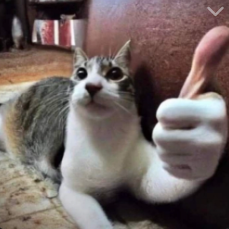

In [14]:
cancelled = df_full[df_full['InvoiceNo'].astype(str).str.startswith('C')]
print(cancelled)

       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

            InvoiceDate  UnitPrice  CustomerID         Country  
141      12/1/2010 9:41      27.50     14527.0



> All of the Invoices that started wtih C exhhibited Cancelled orders, Which were later removed



In [15]:
df_full[df_full['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [16]:
df_full[df_full['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,12/3/2010 12:08,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,12/3/2010 12:08,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,12/3/2010 16:50,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/2010 14:02,0.0,12647.0,Germany
13217,537425,84968F,check,-20,12/6/2010 15:35,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535336,581213,22576,check,-30,12/7/2011 18:38,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,12/8/2011 9:56,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom


In [17]:
df_full['Revenue']=df_full['Quantity']*df_full['UnitPrice']
df_customer['Revenue']=df_customer['Quantity']*df_customer['UnitPrice']

In [18]:
df_full.shape

(540455, 9)

In [19]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 540455 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    540455 non-null  object 
 1   StockCode    540455 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     540455 non-null  int64  
 4   InvoiceDate  540455 non-null  object 
 5   UnitPrice    540455 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      540455 non-null  object 
 8   Revenue      540455 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 41.2+ MB


In [20]:
(df_full.isnull().sum() / len(df_full)) * 100

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.000000
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.724723
Country,0.000000
Revenue,0.000000


In [21]:
df_full[df_full.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom,4.95
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom,2.10
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,1.25
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,1.25
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom,2.95
...,...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/2011 11:34,0.39,14446.0,United Kingdom,0.39
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/2011 11:34,2.49,14446.0,United Kingdom,2.49
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/2011 11:34,1.95,14446.0,United Kingdom,1.95
541699,581538,22694,WICKER STAR,1,12/9/2011 11:34,2.10,14446.0,United Kingdom,2.10


In [22]:
df_full.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom,54.08


In [23]:
df[df['StockCode'].astype(str).str.len()<5]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
45,536370,POST,POSTAGE,3,12/1/2010 8:45,18.00,12583.0,France,54.00
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,-27.50
386,536403,POST,POSTAGE,1,12/1/2010 11:27,15.00,12791.0,Netherlands,15.00
1123,536527,POST,POSTAGE,1,12/1/2010 13:04,18.00,12662.0,Germany,18.00
1423,536540,C2,CARRIAGE,1,12/1/2010 14:05,50.00,14911.0,EIRE,50.00
...,...,...,...,...,...,...,...,...,...
541216,581494,POST,POSTAGE,2,12/9/2011 10:13,18.00,12518.0,Germany,36.00
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom,-224.69
541730,581570,POST,POSTAGE,1,12/9/2011 11:59,18.00,12662.0,Germany,18.00
541767,581574,POST,POSTAGE,2,12/9/2011 12:09,18.00,12526.0,Germany,36.00




> Noticed that majority of the cells StockCode of customer purchases were only length of 5 thus the decision to inspect all of the stock codes of length greater than or lesser than 5



In [24]:
abnormal_codes = df[
    df['StockCode']
    .astype(str)
    .str.contains('[A-Za-z]', regex=True)
]['StockCode'].unique()

# print(abnormal_codes)

In [25]:
# df_customer=df[df['StockCode'].astype(str).str.len()>5]

In [26]:
# df_customer=df_customer[df_customer['StockCode'].astype(str).str.len()<7]

In [27]:
df_customer=df_customer[df_customer['StockCode'].astype(str).str.contains(r'\d',regex=True)]

In [28]:
df_customer[df_customer['StockCode'].astype(str).str.len()>6]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
132,536381,15056BL,EDWARDIAN PARASOL BLACK,2,12/1/2010 9:41,5.95,15311.0,United Kingdom,11.90
281,536396,15056BL,EDWARDIAN PARASOL BLACK,6,12/1/2010 10:51,4.95,17850.0,United Kingdom,29.70
1219,536531,15056BL,EDWARDIAN PARASOL BLACK,12,12/1/2010 13:23,5.95,15485.0,United Kingdom,71.40
4164,536750,15056BL,EDWARDIAN PARASOL BLACK,6,12/2/2010 14:04,4.95,17850.0,United Kingdom,29.70
4185,536752,15056BL,EDWARDIAN PARASOL BLACK,6,12/2/2010 14:06,4.95,17850.0,United Kingdom,29.70
...,...,...,...,...,...,...,...,...,...
528086,580727,15056BL,EDWARDIAN PARASOL BLACK,1,12/5/2011 17:17,12.46,14096.0,United Kingdom,12.46
530982,580893,15056BL,EDWARDIAN PARASOL BLACK,1,12/6/2011 12:38,5.95,17290.0,United Kingdom,5.95
533673,581098,15056BL,EDWARDIAN PARASOL BLACK,6,12/7/2011 11:42,5.95,14911.0,EIRE,35.70
536964,581232,15056BL,EDWARDIAN PARASOL BLACK,24,12/8/2011 10:26,5.95,12358.0,Austria,142.80


In [29]:
df_customer=df_customer[df_customer['Revenue']>0]

In [30]:
df_customer['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)



> Removed the StockCode that do not show purchases of customer


> Removed all negatice Revenue datapoints as they indicated either faulty datapoints or return which is not useful for customer segmentation of low,mid or high revenue customers





> **Handled StockCode, Revenue,Quantity,UnitPrice**


> **Invoice No is fine as it is, Removed C through removing negative Revenue**





In [31]:
df_customer[df_customer['Country']=='European Community']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
168149,551013,22839,3 TIER CAKE TIN GREEN AND CREAM,1,4/26/2011 10:54,14.95,15108.0,European Community,14.95
168150,551013,22840,ROUND CAKE TIN VINTAGE RED,2,4/26/2011 10:54,7.95,15108.0,European Community,15.90
168151,551013,22841,ROUND CAKE TIN VINTAGE GREEN,2,4/26/2011 10:54,7.95,15108.0,European Community,15.90
168152,551013,22457,NATURAL SLATE HEART CHALKBOARD,6,4/26/2011 10:54,2.95,15108.0,European Community,17.70
168153,551013,22314,OFFICE MUG WARMER CHOC+BLUE,6,4/26/2011 10:54,2.95,15108.0,European Community,17.70
168154,551013,22312,OFFICE MUG WARMER POLKADOT,6,4/26/2011 10:54,2.95,15108.0,European Community,17.70
168155,551013,22842,BISCUIT TIN VINTAGE RED,2,4/26/2011 10:54,6.75,15108.0,European Community,13.50
168156,551013,22843,BISCUIT TIN VINTAGE GREEN,2,4/26/2011 10:54,6.75,15108.0,European Community,13.50
168157,551013,22424,ENAMEL BREAD BIN CREAM,1,4/26/2011 10:54,12.75,15108.0,European Community,12.75
168158,551013,22722,SET OF 6 SPICE TINS PANTRY DESIGN,4,4/26/2011 10:54,3.95,15108.0,European Community,15.80


# **Feature engineering is done**


---
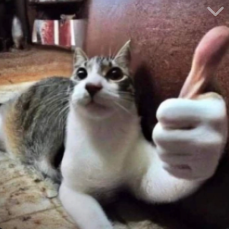


# **Exploratory Data Analysis**


---



In [32]:
df_customer.describe()

,Quantity,UnitPrice,CustomerID,Revenue
count,396470.000000,396470.000000,396470.000000,396470.000000
mean,13.008520,2.884078,15301.447920,22.114542
std,179.611245,4.354473,1709.773015,308.847782
min,1.000000,0.040000,12346.000000,0.060000
25%,2.000000,1.250000,13975.000000,4.680000
50%,6.000000,1.950000,15159.000000,11.800000
75%,12.000000,3.750000,16801.000000,19.800000
max,80995.000000,649.500000,18287.000000,168469.600000


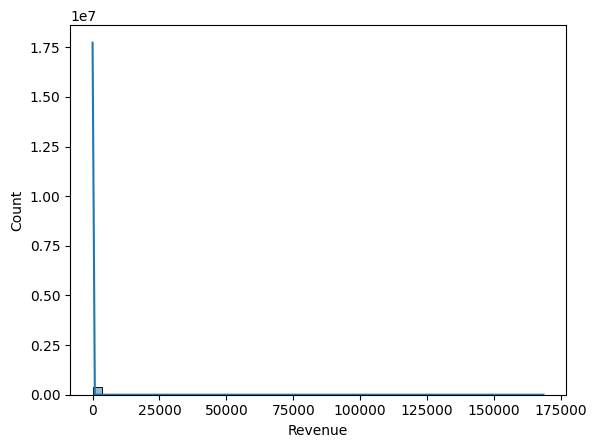

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df_customer['Revenue'], bins=50, kde=True)
plt.show()



> Majority of the Revenue lies in the range of under 20, With massive outliers of 5000 that seems like a extreme case


In [34]:
df_customer[df_customer['Revenue']>4000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
52134,540689,22470,HEART OF WICKER LARGE,1284,1/11/2011 8:43,3.21,17450.0,United Kingdom,4121.64
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,1/11/2011 12:55,2.55,15749.0,United Kingdom,4921.50
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,1/11/2011 12:55,2.10,15749.0,United Kingdom,6539.40
52772,540818,48185,DOORMAT FAIRY CAKE,670,1/11/2011 12:57,6.75,15749.0,United Kingdom,4522.50
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,77183.60
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,4/18/2011 13:20,2.40,15749.0,United Kingdom,4632.00
160544,550461,48185,DOORMAT FAIRY CAKE,670,4/18/2011 13:20,6.35,15749.0,United Kingdom,4254.50
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,4/18/2011 13:20,2.10,15749.0,United Kingdom,6539.40
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,6/10/2011 15:28,649.50,15098.0,United Kingdom,38970.00
244419,558526,23173,REGENCY TEAPOT ROSES,540,6/30/2011 11:01,8.15,17949.0,United Kingdom,4401.00


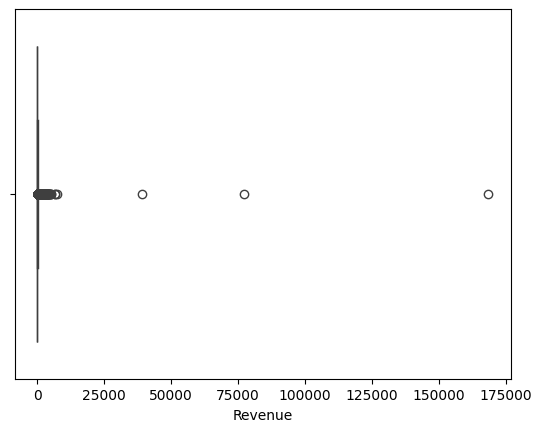

In [35]:
sns.boxplot(x=df_customer['Revenue'])
plt.show()

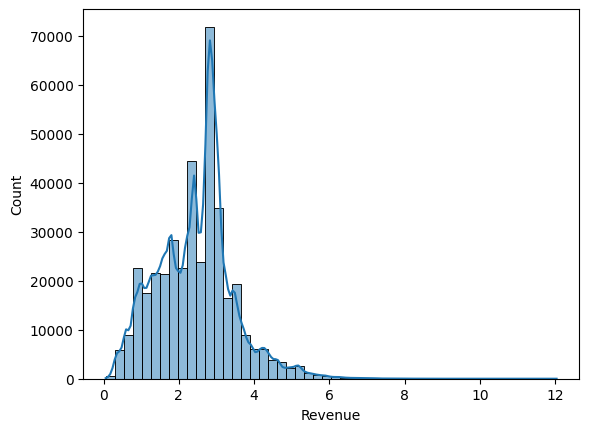

In [36]:
import numpy as np
sns.histplot(np.log1p(df_customer['Revenue']), bins=50, kde=True)
plt.show()

In [37]:
df_customer[df_customer['InvoiceNo'].astype(str).str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue




> Removing -ve Revenue removed the 'C' invoices to also be removed



In [38]:
df_customer['Revenue'].describe()

,Revenue
count,396470.000000
mean,22.114542
std,308.847782
min,0.060000
25%,4.680000
50%,11.800000
75%,19.800000
max,168469.600000


In [39]:
df_customer['Revenue'].skew()

np.float64(453.96509350821094)

In [40]:
df_customer['Revenue'].kurtosis()

np.float64(233657.68176209516)

In [41]:
df_customer['Revenue'].quantile([0.25,0.5,0.75,0.90,0.95,0.99])

,Revenue
0.25,4.68
0.50,11.80
0.75,19.80
0.90,35.40
0.95,67.50
0.99,199.68




> **Log transforming Revenue for outlier handling(removed)**



In [42]:
# df_customer['Revenue_Log'] = np.log1p(df_customer['Revenue'])

# **Making the dataframe represent a customer per data point**

In [43]:
df_customer['InvoiceDate'] = pd.to_datetime(df_customer['InvoiceDate'])

In [44]:
customer_df = df_customer.groupby('CustomerID').agg({
    'Revenue':'sum',
    'InvoiceNo':'nunique',
    'InvoiceDate':'max'
})

In [45]:
print(df_customer.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')


In [46]:
customer_df

,Revenue,InvoiceNo,InvoiceDate
CustomerID,,,
12346.0,77183.60,1,2011-01-18 10:01:00
12347.0,4310.00,7,2011-12-07 15:52:00
12348.0,1437.24,4,2011-09-25 13:13:00
12349.0,1457.55,1,2011-11-21 09:51:00
12350.0,294.40,1,2011-02-02 16:01:00
...,...,...,...
18280.0,180.60,1,2011-03-07 09:52:00
18281.0,80.82,1,2011-06-12 10:53:00
18282.0,178.05,2,2011-12-02 11:43:00


In [47]:
customer_df = customer_df.rename(columns={
    'Revenue':'Monetary',
    'InvoiceNo':'Frequency',
    'InvoiceDate':'Last_Purchase_Date'
})

In [48]:
customer_df

,Monetary,Frequency,Last_Purchase_Date
CustomerID,,,
12346.0,77183.60,1,2011-01-18 10:01:00
12347.0,4310.00,7,2011-12-07 15:52:00
12348.0,1437.24,4,2011-09-25 13:13:00
12349.0,1457.55,1,2011-11-21 09:51:00
12350.0,294.40,1,2011-02-02 16:01:00
...,...,...,...
18280.0,180.60,1,2011-03-07 09:52:00
18281.0,80.82,1,2011-06-12 10:53:00
18282.0,178.05,2,2011-12-02 11:43:00


In [49]:
latest_date = df_customer['InvoiceDate'].max()

print(latest_date)

2011-12-09 12:50:00


In [50]:
customer_df['Recency'] = (
    latest_date - customer_df['Last_Purchase_Date']
).dt.days



> **Added a column for the recent days**



In [51]:
customer_df

,Monetary,Frequency,Last_Purchase_Date,Recency
CustomerID,,,,
12346.0,77183.60,1,2011-01-18 10:01:00,325
12347.0,4310.00,7,2011-12-07 15:52:00,1
12348.0,1437.24,4,2011-09-25 13:13:00,74
12349.0,1457.55,1,2011-11-21 09:51:00,18
12350.0,294.40,1,2011-02-02 16:01:00,309
...,...,...,...,...
18280.0,180.60,1,2011-03-07 09:52:00,277
18281.0,80.82,1,2011-06-12 10:53:00,180
18282.0,178.05,2,2011-12-02 11:43:00,7


In [52]:
customer_df = customer_df.drop('Last_Purchase_Date', axis=1)

In [53]:
customer_df.head()

,Monetary,Frequency,Recency
CustomerID,,,
12346.0,77183.60,1,325
12347.0,4310.00,7,1
12348.0,1437.24,4,74
12349.0,1457.55,1,18
12350.0,294.40,1,309


In [54]:
customer_df = customer_df.reset_index()

In [55]:
X = customer_df.drop('CustomerID', axis=1)

In [56]:
X

,Monetary,Frequency,Recency
0,77183.60,1,325
1,4310.00,7,1
2,1437.24,4,74
3,1457.55,1,18
4,294.40,1,309
...,...,...,...
4329,180.60,1,277
4330,80.82,1,180
4331,178.05,2,7
4332,2088.93,16,3


In [57]:
X.describe()

,Monetary,Frequency,Recency
count,4334.000000,4334.000000,4334.000000
mean,2023.016301,4.246654,91.703046
std,8924.198162,7.642535,100.177047
min,3.750000,1.000000,0.000000
25%,305.867500,1.000000,17.000000
50%,668.125000,2.000000,50.000000
75%,1631.622500,5.000000,142.000000
max,279138.020000,206.000000,373.000000


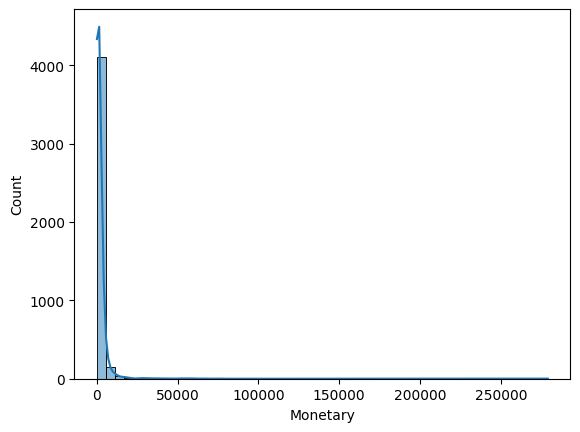

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(X['Monetary'], bins=50, kde=True)
plt.show()

In [59]:
X.skew()

,0
Monetary,19.537908
Frequency,11.976299
Recency,1.242934


# **EDA IS DONE**


---
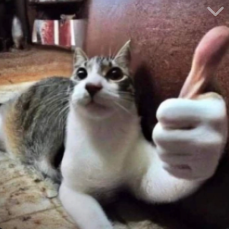


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler
import numpy as np

X = customer_df[
    ['Monetary', 'Frequency', 'Recency']
]

# Pipeline
numeric_pipeline = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, X.columns)
])

# Processed data
X_processed = preprocessor.fit_transform(X)

k=2 --> Silhouette Score = 0.429
k=3 --> Silhouette Score = 0.334
k=4 --> Silhouette Score = 0.336
k=5 --> Silhouette Score = 0.303
k=6 --> Silhouette Score = 0.310
k=7 --> Silhouette Score = 0.305
k=8 --> Silhouette Score = 0.269
k=9 --> Silhouette Score = 0.278
k=10 --> Silhouette Score = 0.281


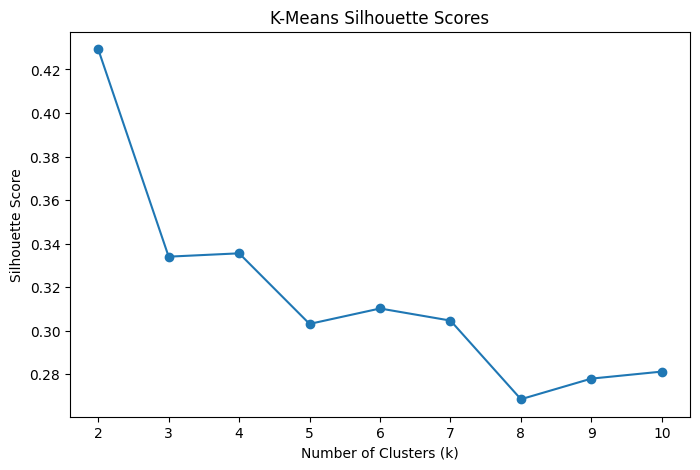

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    cluster_labels = kmeans.fit_predict(
        X_processed
    )

    score = silhouette_score(
        X_processed,
        cluster_labels
    )

    silhouette_scores.append(score)

    print(
        f"k={k} --> Silhouette Score = {score:.3f}"
    )

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title(
    'K-Means Silhouette Scores'
)

plt.xlabel('Number of Clusters (k)')

plt.ylabel('Silhouette Score')

plt.show()

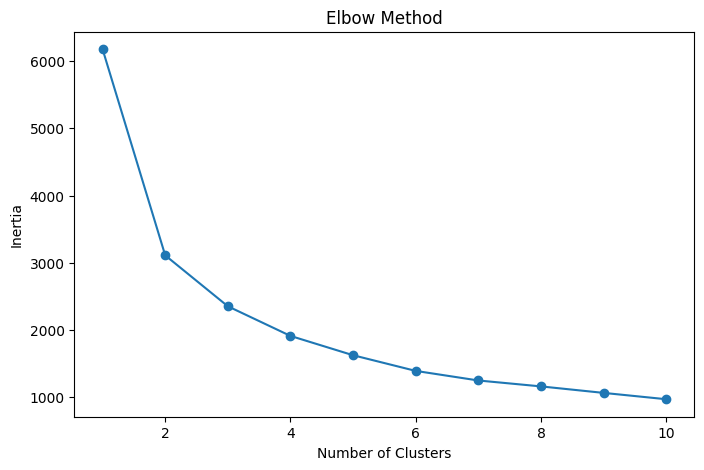

In [62]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_processed)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [63]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):  # silhouette score needs at least 2 clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_processed)

    score = silhouette_score(X_processed, labels)

    silhouette_scores.append(score)

    print(f"k={k} --> Silhouette Score = {score:.3f}")

k=2 --> Silhouette Score = 0.429
k=3 --> Silhouette Score = 0.334
k=4 --> Silhouette Score = 0.336
k=5 --> Silhouette Score = 0.303
k=6 --> Silhouette Score = 0.310
k=7 --> Silhouette Score = 0.305
k=8 --> Silhouette Score = 0.269
k=9 --> Silhouette Score = 0.278
k=10 --> Silhouette Score = 0.281




> **Took the value of K-means as 4 according to the elbow in the graph**


> The value of the graph flattens after the point of 4





In [64]:
from sklearn.cluster import KMeans

# Create KMeans model
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Train model and predict clusters
clusters = kmeans.fit_predict(X_processed)

# Add cluster labels to dataframe
customer_df['Cluster'] = clusters

In [65]:
customer_df.groupby('Cluster').mean()

,CustomerID,Monetary,Frequency,Recency
Cluster,,,,
0,15377.767383,600.348369,2.360303,14.890013
1,15345.128125,303.051113,1.288750,175.979375
2,15213.280453,8074.884816,13.709632,11.219547
3,15238.772838,1703.416839,3.877930,77.748585


# **What the table means**


| Cluster | Spending    | Purchase Frequency | Days Since Last Purchase | Customer Type                   |
| ------- | ----------- | ------------------ | ------------------------ | ------------------------------- |
| 0       | Medium      | Medium             | Low                      | Active Regular Customers        |
| 1       | Low         | Low                | High                     | Inactive / Churn-Risk Customers |
| 2       | High        | High               | Low                      | VIP / Loyal Customers           |
| 3       | Medium-High | Medium-High        | Medium                   | Potential Loyal Customers       |



In [66]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    X_processed,
    customer_df['Cluster']
)

print("K-Means Silhouette Score:",
      round(kmeans_score, 3))

K-Means Silhouette Score: 0.336


In [67]:
customer_df['Cluster'].value_counts()

,count
Cluster,
1,1600
3,1237
0,791
2,706


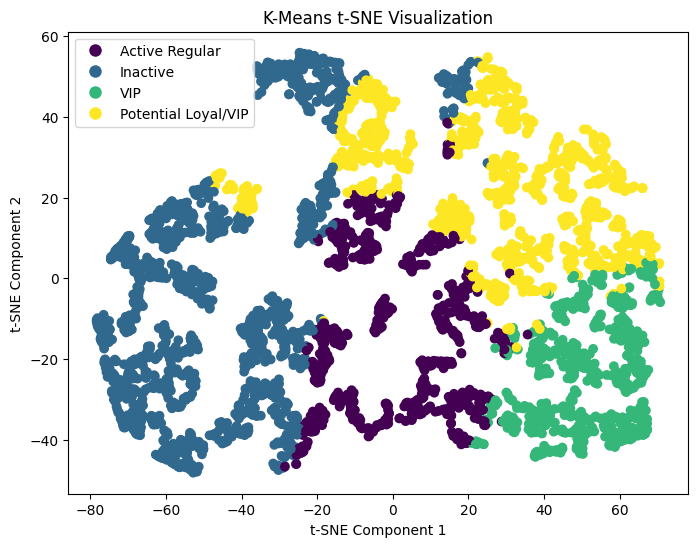

In [68]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_features = tsne.fit_transform(X_processed)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    tsne_features[:,0],
    tsne_features[:,1],
    c=customer_df['Cluster'],
    cmap='viridis'
)

plt.title('K-Means t-SNE Visualization')

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Legend
legend_elements = [

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Active Regular',
           markerfacecolor=plt.cm.viridis(0.0),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Inactive',
           markerfacecolor=plt.cm.viridis(0.33),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='VIP',
           markerfacecolor=plt.cm.viridis(0.66),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Potential Loyal/VIP',
           markerfacecolor=plt.cm.viridis(1.0),
           markersize=10)
]

plt.legend(handles=legend_elements)

plt.show()

In [69]:
import pandas as pd

processed_df = pd.DataFrame(
    X_processed,
    columns=X.columns
)

processed_df.describe()

,Monetary,Frequency,Recency
count,4334.000000,4334.000000,4334.000000
mean,0.045115,0.221237,-0.078607
std,0.749975,0.620636,0.691408
min,-2.960064,-0.369070,-1.897166
25%,-0.466373,-0.369070,-0.502517
50%,0.000000,0.000000,0.000000
75%,0.533627,0.630930,0.497483
max,3.609570,3.854050,0.961378


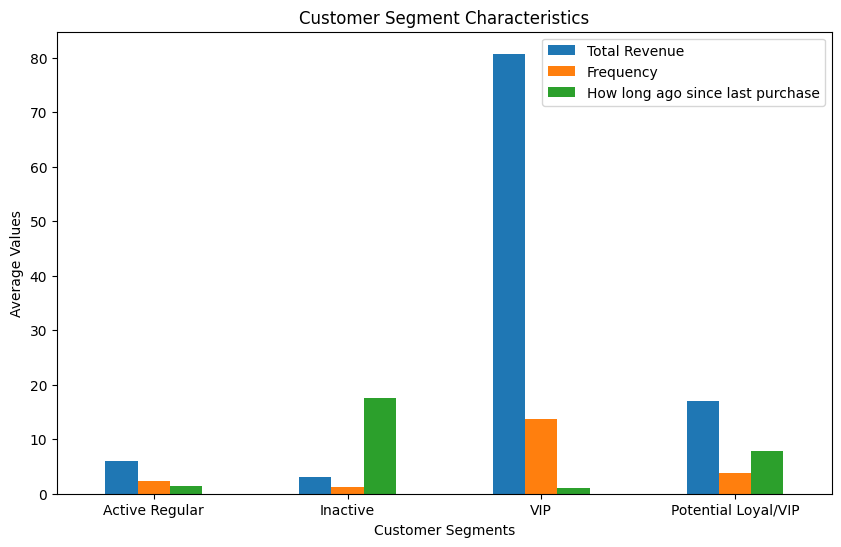

In [70]:
import matplotlib.pyplot as plt

# Cluster summary
cluster_summary = customer_df.groupby('Cluster')[[
    'Monetary',
    'Frequency',
    'Recency'
]].mean()

# Compress Monetary values
cluster_summary['Monetary'] = (
    cluster_summary['Monetary'] / 100
)
#supress Recency values
cluster_summary['Recency'] = (
    cluster_summary['Recency'] / 10
)
# Rename clusters
cluster_summary.index = [
    'Active Regular',
    'Inactive',
    'VIP',
    'Potential Loyal/VIP'
]

# Plot
cluster_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Customer Segment Characteristics')
plt.xlabel('Customer Segments')
plt.ylabel('Average Values')

plt.xticks(rotation=0)

plt.legend([
    'Total Revenue ',
    'Frequency',
    'How long ago since last purchase'
])

plt.show()

### Graph Explanation

The graph represents the characteristics of different customer segments identified using K-Means clustering based on three factors: Monetary value (customer spending), Frequency (number of purchases), and Recency (days since last purchase).

- **VIP customers** have the highest spending and purchase frequency while purchasing recently, making them the most valuable customer group.
- **Inactive customers** show low spending and low purchase frequency with very high recency, indicating that they have not purchased for a long time.
- **Active Regular customers** purchase consistently with moderate spending and recent activity.
- **Potential Loyal customers** have relatively high spending and frequency but are less active than VIP customers, indicating potential for future loyalty growth.

# **Starting with PCA**


---



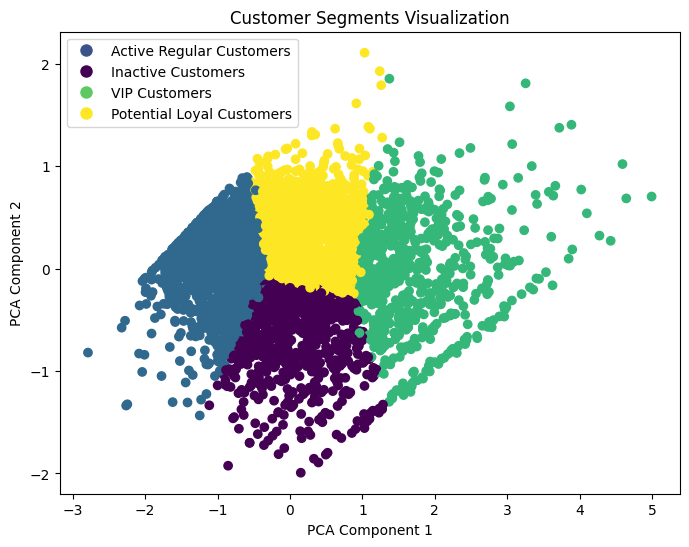

In [71]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

# PCA Scatter Plot
plt.figure(figsize=(8,6))

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_processed)

scatter = plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=customer_df['Cluster'],
    cmap='viridis'
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.title('Customer Segments Visualization')

# Custom Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Active Regular Customers',
        markerfacecolor=plt.cm.viridis(0.25),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Inactive Customers',
        markerfacecolor=plt.cm.viridis(0.0),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='VIP Customers',
        markerfacecolor=plt.cm.viridis(0.75),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Potential Loyal Customers',
        markerfacecolor=plt.cm.viridis(1.0),
        markersize=10
    )
]

plt.legend(handles=legend_elements)

plt.show()

##PCA Visualization Explanation

- PCA reduces the customer data into 2 dimensions for easier visualization.
- Each point in the graph represents a customer.
- Customers closer together have similar purchasing behavior.
- Different colors represent different customer segments identified by K-Means clustering.





In [72]:
pca.components_

array([[ 0.66220926,  0.54842864, -0.51059272],
       [ 0.49836903,  0.18649364,  0.84666902]])

# **K-Means is DONE**


---

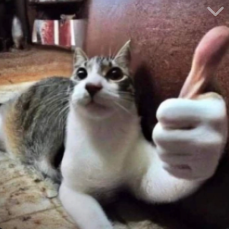

# **Hierarchical Clustering**


---



In [73]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [74]:
linked = linkage(
    X_processed,
    method='ward'
)

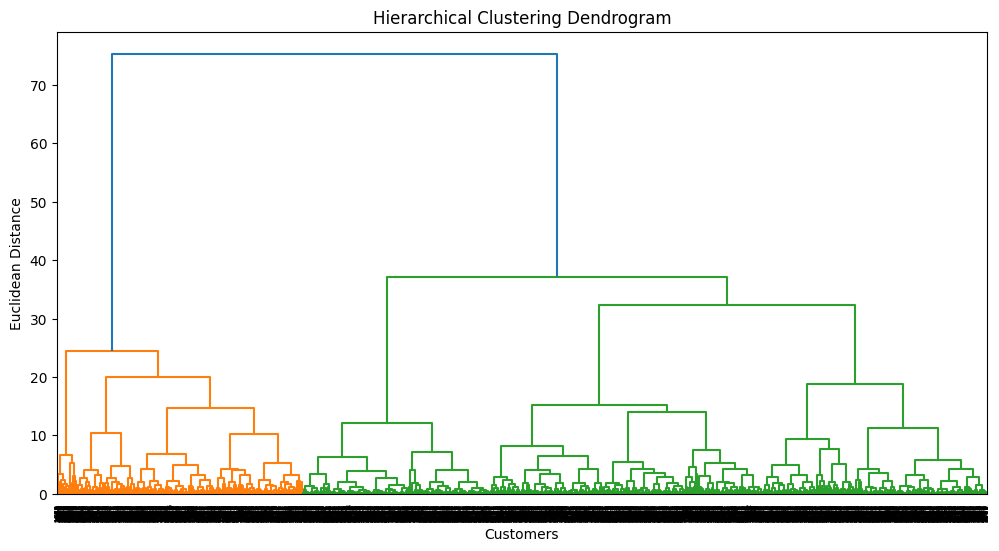

In [75]:
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title('Hierarchical Clustering Dendrogram')

plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

plt.show()

In [76]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

k_values = range(2, 11)

for k in k_values:

    hc = AgglomerativeClustering(
        n_clusters=k
    )

    cluster_labels = hc.fit_predict(
        X_processed
    )

    score = silhouette_score(
        X_processed,
        cluster_labels
    )

    silhouette_scores.append(score)

    print(
        f"k={k} --> Silhouette Score = {score:.3f}"
    )



k=2 --> Silhouette Score = 0.425
k=3 --> Silhouette Score = 0.266
k=4 --> Silhouette Score = 0.285
k=5 --> Silhouette Score = 0.282
k=6 --> Silhouette Score = 0.273
k=7 --> Silhouette Score = 0.256
k=8 --> Silhouette Score = 0.226
k=9 --> Silhouette Score = 0.220
k=10 --> Silhouette Score = 0.229




> **Stuck to K=4 since K=2 will only classify the customers into VIP/Non-VIP which is not the proper information needed**



In [77]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4
)

hc_clusters = hc.fit_predict(X_processed)

In [78]:
customer_df['HC_Cluster'] = hc_clusters

In [79]:
from sklearn.metrics import silhouette_score

hc_score = silhouette_score(
    X_processed,
    customer_df['HC_Cluster']
)

print("Hierarchical Silhouette Score:",
      round(hc_score, 3))

Hierarchical Silhouette Score: 0.285


In [80]:
customer_df.groupby('HC_Cluster').mean()

,CustomerID,Monetary,Frequency,Recency,Cluster
HC_Cluster,,,,,
0,15225.070557,5530.708859,10.503484,18.671603,2.070557
1,15425.822627,343.803538,1.595398,38.069032,0.503356
2,15395.409611,247.001281,1.176201,244.551487,1.000000
3,15196.103231,1453.138432,2.880221,96.581560,2.322301


# **What the table means:**

| HC Cluster | Monetary    | Frequency | Recency     | Customer Type              |
| ---------- | ----------- | --------- | ----------- | -------------------------- |
| 0          | Very High   | Very High | Low         | VIP Customers              |
| 1          | Low         | Low       | Low-Medium  | Active Low-Value Customers |
| 2          | Very Low    | Very Low  | Very High   | Inactive Customers         |
| 3          | Medium-High | Medium    | Medium-High | Regular Customers          |


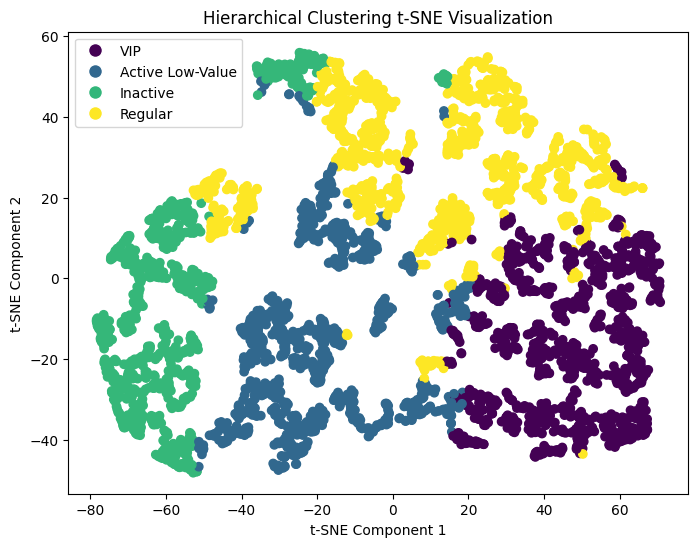

In [81]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_features_hc = tsne.fit_transform(X_processed)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    tsne_features_hc[:,0],
    tsne_features_hc[:,1],
    c=customer_df['HC_Cluster'],
    cmap='viridis'
)

plt.title('Hierarchical Clustering t-SNE Visualization')

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Legend
legend_elements = [

    Line2D([0],[0],
           marker='o',
           color='w',
           label='VIP',
           markerfacecolor=plt.cm.viridis(0.0),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Active Low-Value',
           markerfacecolor=plt.cm.viridis(0.33),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Inactive',
           markerfacecolor=plt.cm.viridis(0.66),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Regular',
           markerfacecolor=plt.cm.viridis(1.0),
           markersize=10)
]

plt.legend(handles=legend_elements)

plt.show()

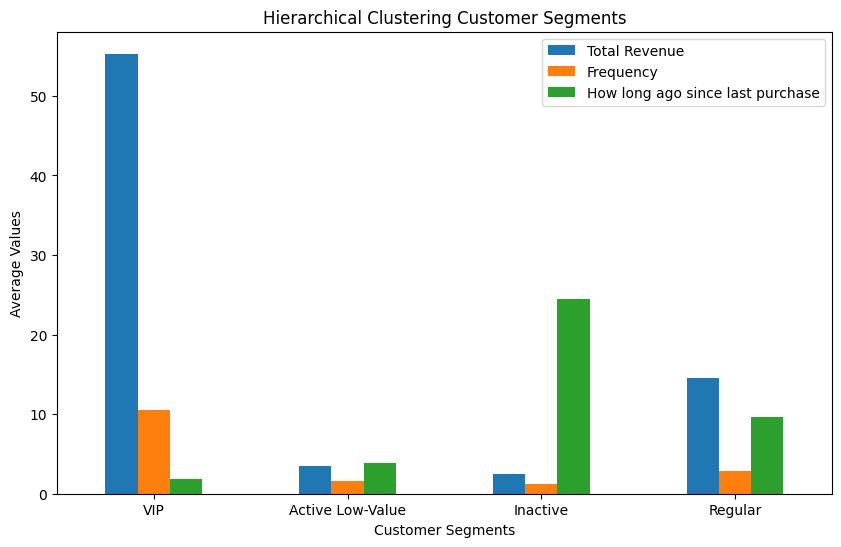

In [82]:
import matplotlib.pyplot as plt

# Hierarchical cluster summary
hc_summary = customer_df.groupby('HC_Cluster')[[
    'Monetary',
    'Frequency',
    'Recency'
]].mean()

# Compress Monetary values
hc_summary['Monetary'] = (
    hc_summary['Monetary'] / 100
)

# Compress Recency values
hc_summary['Recency'] = (
    hc_summary['Recency'] / 10
)

# Rename clusters
hc_summary.index = [
    'VIP',
    'Active Low-Value',
    'Inactive',
    'Regular'
]

# Plot
hc_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Hierarchical Clustering Customer Segments')
plt.xlabel('Customer Segments')
plt.ylabel('Average Values')

plt.xticks(rotation=0)

plt.legend([
    'Total Revenue',
    'Frequency',
    'How long ago since last purchase'
])

plt.show()

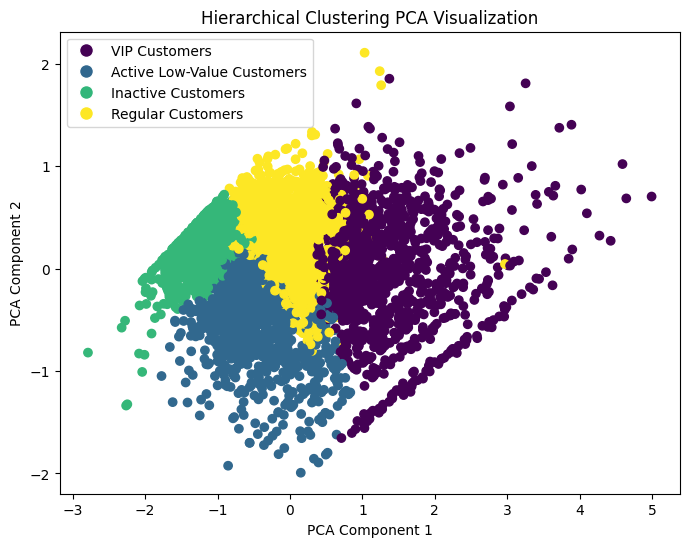

In [83]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Apply PCA
pca = PCA(n_components=2)

pca_features_hc = pca.fit_transform(X_processed)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    pca_features_hc[:,0],
    pca_features_hc[:,1],
    c=customer_df['HC_Cluster'],
    cmap='viridis'
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.title('Hierarchical Clustering PCA Visualization')

# Custom Legend
legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='VIP Customers',
        markerfacecolor=plt.cm.viridis(0.0),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Active Low-Value Customers',
        markerfacecolor=plt.cm.viridis(0.33),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Inactive Customers',
        markerfacecolor=plt.cm.viridis(0.66),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Regular Customers',
        markerfacecolor=plt.cm.viridis(1.0),
        markersize=10
    )
]

plt.legend(handles=legend_elements)

plt.show()



> **Hierarchical CLustering does not have a smooth variance thus the difficulty with seperating them in the PCA, Proving that K-Means was performing better with the current customer df**



# **Hierarchical Clustering is done**


---

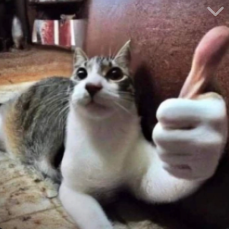

# **DBSCAN**


---



In [84]:
# Create separate copy for DBSCAN
dbscan_df = X.copy()

# Cap extreme Monetary outliers
dbscan_df['Monetary'] = dbscan_df['Monetary'].clip(
    upper=dbscan_df['Monetary'].quantile(0.99)
)

In [85]:
# Process DBSCAN data separately
X_dbscan_processed = preprocessor.fit_transform(
    dbscan_df
)



> **Made a copy of the Dataframe to handle the outliers in them**


> also changed the eps to 0.35 since 0.7 puts all into a single cluster




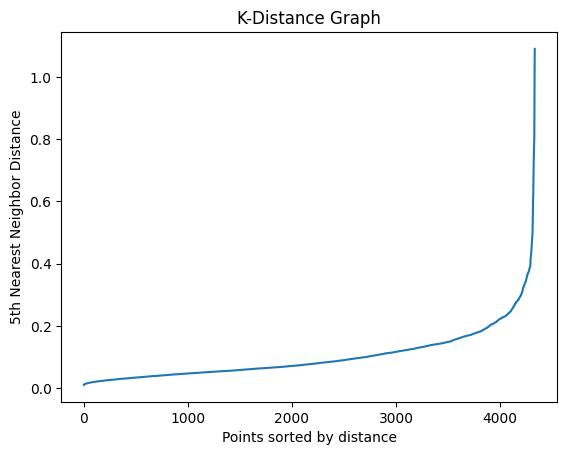

In [95]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(X_dbscan_processed)

distances, indices = neighbors_fit.kneighbors(X_dbscan_processed)

distances = np.sort(distances[:,4])

plt.plot(distances)

plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")

plt.title("K-Distance Graph")

plt.show()



> **From the graph it was understood that the best eps values to be tried are between 0.25-0.35**



In [97]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [0.25, 0.28, 0.30, 0.32, 0.35]

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_dbscan_processed)

    mask = labels != -1

    n_clusters = len(set(labels[mask]))

    if n_clusters > 1:

        score = silhouette_score(
            X_dbscan_processed[mask],
            labels[mask]
        )

        print(
            f"eps={eps} | "
            f"clusters={n_clusters} | "
            f"score={score:.3f}"
        )

    else:

        print(
            f"eps={eps} -> not enough clusters"
        )

eps=0.25 | clusters=8 | score=0.078
eps=0.28 | clusters=3 | score=0.225
eps=0.3 | clusters=3 | score=0.223
eps=0.32 | clusters=3 | score=0.223
eps=0.35 | clusters=2 | score=0.283




> **eps=0.35 still performing the best among them all**



In [98]:
from sklearn.cluster import DBSCAN

# Create DBSCAN model
dbscan = DBSCAN(
    eps=0.35,
    min_samples=5
)

# Train DBSCAN
dbscan_clusters = dbscan.fit_predict(
    X_dbscan_processed
)

# Add clusters
customer_df['DBSCAN_Cluster'] = dbscan_clusters

# View clusters
print(customer_df['DBSCAN_Cluster'].unique())

[-1  0  1  2  7  3  4  5  6]


In [99]:
from sklearn.metrics import silhouette_score

# Remove noise points
dbscan_mask = (
    customer_df['DBSCAN_Cluster'] != -1
)

# Compute score only if enough clusters exist
if len(set(
    customer_df.loc[
        dbscan_mask,
        'DBSCAN_Cluster'
    ]
)) > 1:

    dbscan_score = silhouette_score(
        X_dbscan_processed[dbscan_mask],
        customer_df.loc[
            dbscan_mask,
            'DBSCAN_Cluster'
        ]
    )

    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_score, 3)
    )

else:
    print(
        "DBSCAN does not have enough clusters"
    )

DBSCAN Silhouette Score: 0.078


In [88]:
# Cluster counts
customer_df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,2803
1,1495
-1,36


In [89]:
# Cluster analysis
customer_df.groupby('DBSCAN_Cluster')[[
    'Monetary',
    'Frequency',
    'Recency'
]].mean()

,Monetary,Frequency,Recency
DBSCAN_Cluster,,,
-1,30932.381111,34.000000,83.388889
0,2540.867260,5.596147,57.709597
1,355.943813,1.000000,155.638127


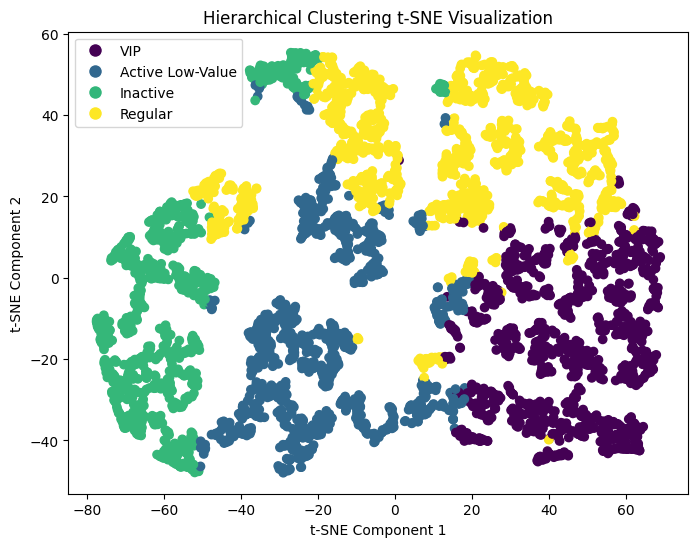

In [90]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_features_hc = tsne.fit_transform(X_dbscan_processed)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    tsne_features_hc[:,0],
    tsne_features_hc[:,1],
    c=customer_df['HC_Cluster'],
    cmap='viridis'
)

plt.title('Hierarchical Clustering t-SNE Visualization')

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Legend
legend_elements = [

    Line2D([0],[0],
           marker='o',
           color='w',
           label='VIP',
           markerfacecolor=plt.cm.viridis(0.0),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Active Low-Value',
           markerfacecolor=plt.cm.viridis(0.33),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Inactive',
           markerfacecolor=plt.cm.viridis(0.66),
           markersize=10),

    Line2D([0],[0],
           marker='o',
           color='w',
           label='Regular',
           markerfacecolor=plt.cm.viridis(1.0),
           markersize=10)
]

plt.legend(handles=legend_elements)

plt.show()



> Cluster 0 represents the majority of normal customers with average spending and purchasing behavior.

> Cluster -1 represents unusual high-value customers detected as outliers due to extremely high spending and purchase frequency.






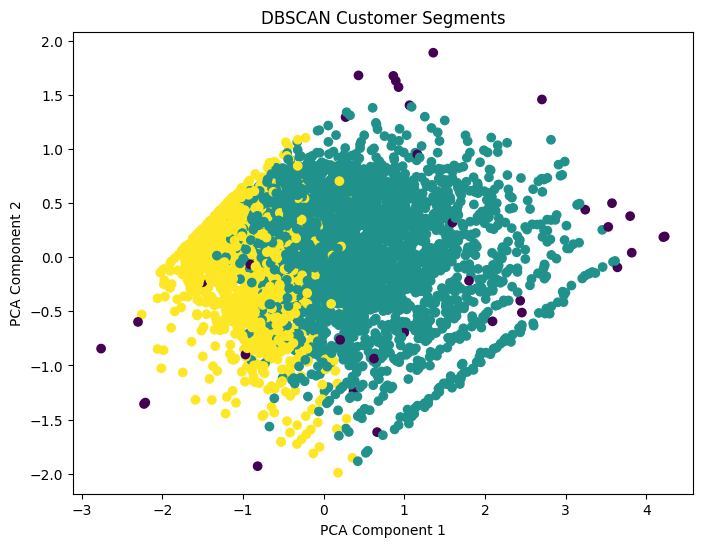

In [91]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA for visualization
pca = PCA(n_components=2)

pca_features_db = pca.fit_transform(X_dbscan_processed)

# Plot DBSCAN clusters
plt.figure(figsize=(8,6))

plt.scatter(
    pca_features_db[:,0],
    pca_features_db[:,1],
    c=customer_df['DBSCAN_Cluster'],
    cmap='viridis'
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.title('DBSCAN Customer Segments')

plt.show()

In [92]:
# Noise points count (-1 means outlier/noise)
(customer_df['DBSCAN_Cluster'] == -1).sum()

np.int64(36)

### DBSCAN Summary

DBSCAN identified one large main customer group and a small number of outlier customers. The algorithm detected that most customers had similar purchasing behavior and belonged to a single dense cluster, while a few customers with extremely high spending and purchase frequency were classified as anomalies. Compared to K-Means and Hierarchical Clustering, DBSCAN produced less meaningful customer segmentation for this dataset because the customer data formed a continuous distribution rather than clearly separated density-based groups.

# Customer Segmentation using Unsupervised Learning

This notebook performs customer segmentation on the Online Retail dataset using multiple unsupervised learning techniques. The dataset was first cleaned by handling duplicates, missing values, invalid stock codes, and irrelevant records. Exploratory Data Analysis (EDA) was then performed to understand customer purchasing behavior, revenue distribution, and outliers.

Feature engineering techniques were applied to create important customer metrics such as:
- Monetary Value (total spending)
- Frequency (number of purchases)
- Recency (days since last purchase)

The data was preprocessed using:
- Log Transformation
- Robust Scaling
- Pipelines and Column Transformers

Multiple clustering algorithms were then implemented and compared:
- K-Means Clustering
- Hierarchical (Agglomerative) Clustering
- DBSCAN

K-Means and Hierarchical Clustering successfully identified meaningful customer segments such as:
- VIP Customers
- Inactive Customers
- Active Regular Customers
- Potential Loyal Customers

DBSCAN mainly identified one large customer group along with a few anomalous high-value customers, making it less effective for this dataset.

Dimensionality reduction techniques such as PCA and t-SNE were used to visualize customer clusters and analyze customer similarity patterns. The results showed that K-Means produced the most balanced and interpretable customer segmentation for the dataset.

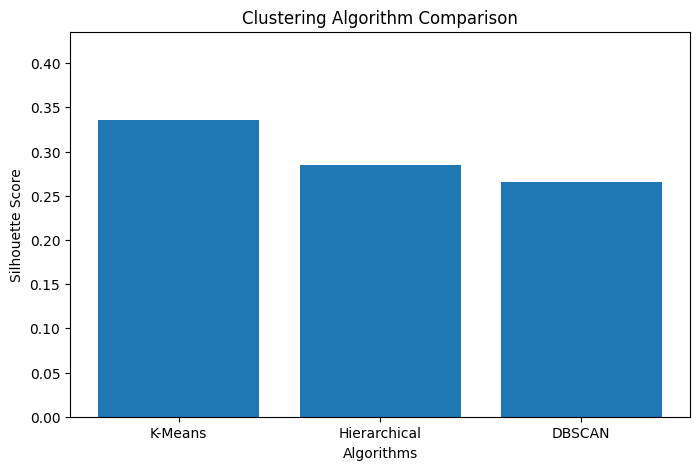